In [1]:
from pathlib import Path

import random

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import models
from torchvision import transforms

from sklearn.metrics import (
    roc_curve,
    auc
)

from sklearn.metrics.pairwise import cosine_similarity

from scipy.spatial.distance import euclidean

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

CHANGE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "change_detection"
)

CHANGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(DEVICE)

cuda


In [4]:
metadata_df = pd.read_csv(

    PROCESSED_DIR
    / "eurosat_geo_clusters.csv"

)

print(metadata_df.shape)

metadata_df.head()

(27000, 7)


,filepath_rgb,filepath_tif,class_name,center_lat,center_lon,class_id,geo_cluster
0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,44.035220,28.559055,0,3
1,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,39.085801,-1.829726,0,5
2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.977295,4.239720,0,2
3,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.892610,4.089878,0,2
4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,51.832851,18.084960,0,6


In [5]:
eval_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [6]:
resnet18 = models.resnet18(

    weights=None

)

resnet18.fc = nn.Linear(

    resnet18.fc.in_features,

    10

)

resnet18.load_state_dict(

    torch.load(

        CHECKPOINT_DIR
        / "resnet18_finetuned_best.pt",

        map_location=DEVICE

    )

)

resnet18 = resnet18.to(DEVICE)

resnet18.eval()

print("Checkpoint Loaded")

Checkpoint Loaded


In [7]:
feature_extractor = nn.Sequential(

    *list(resnet18.children())[:-1]

)

feature_extractor.eval()

feature_extractor.to(DEVICE)

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [8]:
def extract_embedding(image_path):

    image = Image.open(

        image_path

    ).convert("RGB")

    image = eval_transform(image)

    image = image.unsqueeze(0)

    image = image.to(DEVICE)

    with torch.no_grad():

        embedding = feature_extractor(

            image

        )

    embedding = embedding.squeeze()

    embedding = embedding.cpu().numpy()

    return embedding

In [9]:
sample_path = metadata_df.iloc[0]["filepath_rgb"]

embedding = extract_embedding(sample_path)

print(embedding.shape)

(512,)


In [10]:
cluster_groups = {}

for cluster in sorted(metadata_df["geo_cluster"].unique()):

    cluster_groups[cluster] = metadata_df[
        metadata_df["geo_cluster"] == cluster
    ].reset_index(drop=True)

print(cluster_groups.keys())

dict_keys([np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)])


In [11]:
pairs = []

random.seed(42)

NUM_PAIRS_PER_CLUSTER = 100

for cluster, cluster_df in cluster_groups.items():

    classes = cluster_df["class_name"].unique()

    # ---------- Unchanged ----------

    for cls in classes:

        cls_df = cluster_df[
            cluster_df["class_name"] == cls
        ]

        if len(cls_df) < 2:
            continue

        n_pairs = min(
            NUM_PAIRS_PER_CLUSTER,
            len(cls_df) // 2
        )

        for _ in range(n_pairs):

            idx1, idx2 = random.sample(
                range(len(cls_df)),
                2
            )

            pairs.append({

                "geo_cluster": cluster,

                "t1": cls_df.iloc[idx1]["filepath_rgb"],

                "t2": cls_df.iloc[idx2]["filepath_rgb"],

                "label": 0

            })

    # ---------- Changed ----------

    if len(classes) < 2:
        continue

    for _ in range(NUM_PAIRS_PER_CLUSTER):

        cls1, cls2 = random.sample(
            list(classes),
            2
        )

        df1 = cluster_df[
            cluster_df["class_name"] == cls1
        ]

        df2 = cluster_df[
            cluster_df["class_name"] == cls2
        ]

        row1 = df1.sample(
            n=1,
            random_state=random.randint(0,100000)
        ).iloc[0]

        row2 = df2.sample(
            n=1,
            random_state=random.randint(0,100000)
        ).iloc[0]

        pairs.append({

            "geo_cluster": cluster,

            "t1": row1["filepath_rgb"],

            "t2": row2["filepath_rgb"],

            "label": 1

        })

In [12]:
pairs_df = pd.DataFrame(pairs)

print(pairs_df.shape)

pairs_df.head()

(5580, 4)


,geo_cluster,t1,t2,label
0,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0
1,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0
2,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0
3,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0
4,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0


In [13]:
changed_df = pairs_df[
    pairs_df["label"] == 1
]

unchanged_df = pairs_df[
    pairs_df["label"] == 0
].sample(
    n=len(changed_df),
    random_state=42
)

pairs_df = pd.concat(
    [
        changed_df,
        unchanged_df
    ],
    ignore_index=True
)

pairs_df = pairs_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(pairs_df["label"].value_counts())
print(pairs_df.shape)

label
0    600
1    600
Name: count, dtype: int64
(1200, 4)


In [14]:
pairs_df["label"].value_counts()

label
0    600
1    600
Name: count, dtype: int64

In [15]:
pair_csv = (
    CHANGE_DIR
    / "change_detection_pairs.csv"
)

pairs_df.to_csv(
    pair_csv,
    index=False
)

print(pair_csv)

c:\Users\ASUS\dev\projects\satellite-project\outputs\change_detection\change_detection_pairs.csv


In [16]:
results = []

for _, row in pairs_df.iterrows():

    emb1 = extract_embedding(
        row["t1"]
    )

    emb2 = extract_embedding(
        row["t2"]
    )

    cosine = cosine_similarity(
        emb1.reshape(1, -1),
        emb2.reshape(1, -1)
    )[0][0]

    distance = euclidean(
        emb1,
        emb2
    )

    results.append({

        "geo_cluster": row["geo_cluster"],

        "t1": row["t1"],

        "t2": row["t2"],

        "label": row["label"],

        "cosine_similarity": cosine,

        "euclidean_distance": distance

    })

In [17]:
results_df = pd.DataFrame(results)

print(results_df.shape)

results_df.head()

(1200, 6)


,geo_cluster,t1,t2,label,cosine_similarity,euclidean_distance
0,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0,0.970777,8.128638
1,2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0,0.945028,7.427784
2,2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.467036,30.878260
3,5,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.420829,29.671526
4,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.577342,22.438444


In [18]:
results_df.groupby("label")[
    [
        "cosine_similarity",
        "euclidean_distance"
    ]
].describe()

cosine_similarity                                                    \
                  count      mean       std       min       25%       50%   
label                                                                       
0                 600.0  0.821849  0.094197  0.463030  0.774763  0.830227   
1                 600.0  0.561431  0.127347  0.256703  0.462466  0.557432   

                          euclidean_distance                                  \
            75%       max              count       mean       std        min   
label                                                                          
0      0.885252  0.998407              600.0  15.447856  5.074877   2.444326   
1      0.657816  0.877169              600.0  24.967416  5.932642  10.550813   

                                                   
             25%        50%        75%        max  
label                                              
0      12.165771  15.001861  18.349476  48.463337  
1      20.707381  24.550462  28.476273  44.506889

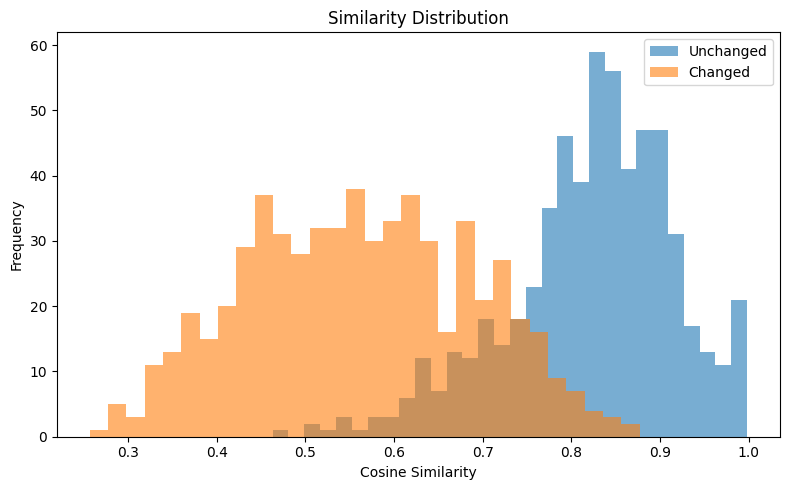

In [19]:
plt.figure(figsize=(8,5))

plt.hist(

    results_df[
        results_df["label"] == 0
    ]["cosine_similarity"],

    bins=30,

    alpha=0.6,

    label="Unchanged"

)

plt.hist(

    results_df[
        results_df["label"] == 1
    ]["cosine_similarity"],

    bins=30,

    alpha=0.6,

    label="Changed"

)

plt.xlabel("Cosine Similarity")

plt.ylabel("Frequency")

plt.title("Similarity Distribution")

plt.legend()

plt.tight_layout()

plt.show()

In [20]:
fpr, tpr, thresholds = roc_curve(

    results_df["label"],

    -results_df["cosine_similarity"]

)

roc_auc = auc(
    fpr,
    tpr
)

print(f"AUC: {roc_auc:.4f}")

AUC: 0.9461


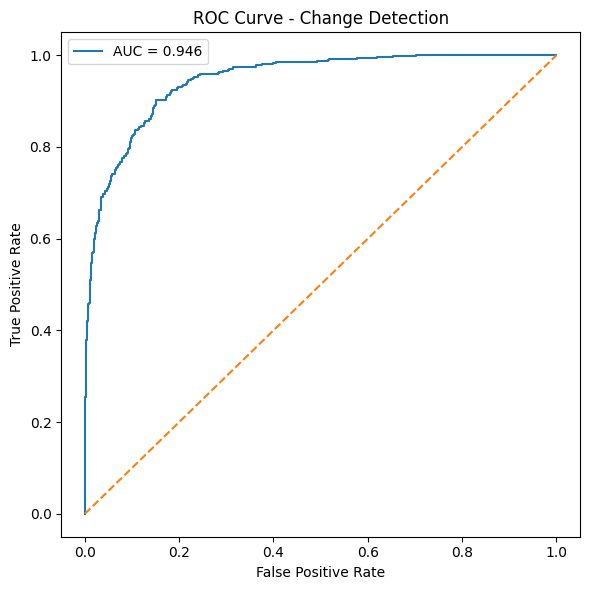

In [21]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Change Detection")

plt.legend()

plt.tight_layout()

plt.savefig(
    CHANGE_DIR /
    "roc_curve.png",
    dpi=300
)

plt.show()

In [22]:
j_scores = tpr - fpr

best_idx = j_scores.argmax()

best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")

print(f"TPR: {tpr[best_idx]:.4f}")

print(f"FPR: {fpr[best_idx]:.4f}")

Best Threshold: -0.7274
TPR: 0.9000
FPR: 0.1500


In [23]:
SIMILARITY_THRESHOLD = 0.7274

results_df["prediction"] = (
    results_df["cosine_similarity"]
    < SIMILARITY_THRESHOLD
).astype(int)

results_df.head()

,geo_cluster,t1,t2,label,cosine_similarity,euclidean_distance,prediction
0,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0,0.970777,8.128638,0
1,2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0,0.945028,7.427784,0
2,2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.467036,30.878260,1
3,5,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.420829,29.671526,1
4,0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.577342,22.438444,1


In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print(
    "Accuracy:",
    accuracy_score(
        results_df["label"],
        results_df["prediction"]
    )
)

print()

print(
    classification_report(
        results_df["label"],
        results_df["prediction"],
        target_names=[
            "Unchanged",
            "Changed"
        ]
    )
)

Accuracy: 0.8741666666666666

              precision    recall  f1-score   support

   Unchanged       0.89      0.85      0.87       600
     Changed       0.86      0.90      0.88       600

    accuracy                           0.87      1200
   macro avg       0.88      0.87      0.87      1200
weighted avg       0.88      0.87      0.87      1200



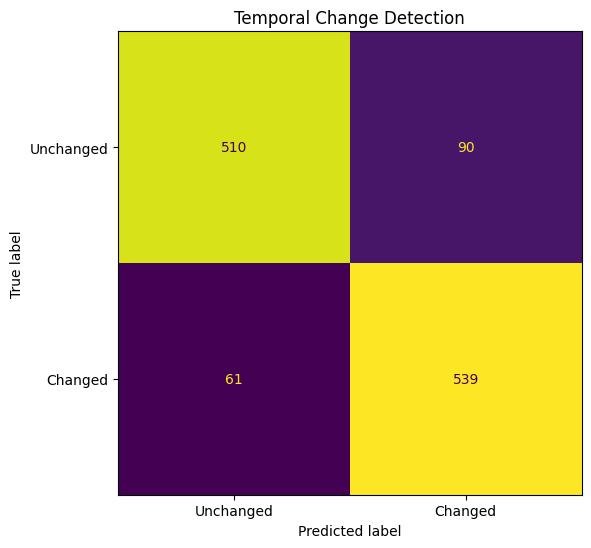

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    results_df["label"],
    results_df["prediction"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Unchanged",
        "Changed"
    ]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    ax=ax,
    colorbar=False
)

plt.title("Temporal Change Detection")

plt.tight_layout()

plt.savefig(
    CHANGE_DIR /
    "change_detection_confusion_matrix.png",
    dpi=300
)

plt.show()

In [26]:
metrics_df = pd.DataFrame({

    "Metric": [
        "AUC",
        "Threshold",
        "Accuracy",
        "TPR",
        "FPR"
    ],

    "Value": [
        roc_auc,
        SIMILARITY_THRESHOLD,
        accuracy_score(
            results_df["label"],
            results_df["prediction"]
        ),
        tpr[best_idx],
        fpr[best_idx]
    ]

})

metrics_df.to_csv(
    CHANGE_DIR / "change_detection_metrics.csv",
    index=False
)

In [27]:
correct_unchanged = results_df[
    (results_df["label"] == 0) &
    (results_df["prediction"] == 0)
].sample(
    2,
    random_state=42
)

correct_changed = results_df[
    (results_df["label"] == 1) &
    (results_df["prediction"] == 1)
].sample(
    2,
    random_state=42
)

misclassified = results_df[
    results_df["label"] !=
    results_df["prediction"]
].sample(
    1,
    random_state=42
)

examples = pd.concat(
    [
        correct_unchanged,
        correct_changed,
        misclassified
    ],
    ignore_index=True
)

examples

,geo_cluster,t1,t2,label,cosine_similarity,euclidean_distance,prediction
0,2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0,0.982796,7.765657,0
1,4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0,0.760646,18.711637,0
2,6,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.381882,28.470478,1
3,6,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,1,0.357988,25.724939,1
4,2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,0,0.652461,24.548239,1


In [28]:
def visualize_change_pair(row, save_index):

    img1 = Image.open(
        row["t1"]
    ).convert("RGB")

    img2 = Image.open(
        row["t2"]
    ).convert("RGB")

    img1_np = np.array(img1)
    img2_np = np.array(img2)

    diff = np.abs(
        img1_np.astype(np.float32)
        -
        img2_np.astype(np.float32)
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15,5)
    )

    axes[0].imshow(img1)
    axes[0].set_title("T1")
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title("T2")
    axes[1].axis("off")

    axes[2].imshow(
        diff.astype(np.uint8)
    )
    axes[2].set_title("Absolute Difference")
    axes[2].axis("off")

    plt.suptitle(

        f"Cluster: {row['geo_cluster']} | "

        f"Similarity: {row['cosine_similarity']:.3f}\n"

        f"Ground Truth: {'Changed' if row['label'] else 'Unchanged'} | "

        f"Prediction: {'Changed' if row['prediction'] else 'Unchanged'}"

    )

    plt.tight_layout()

    plt.savefig(

        CHANGE_DIR /

        f"change_heatmap_{save_index}.png",

        dpi=300

    )

    plt.show()

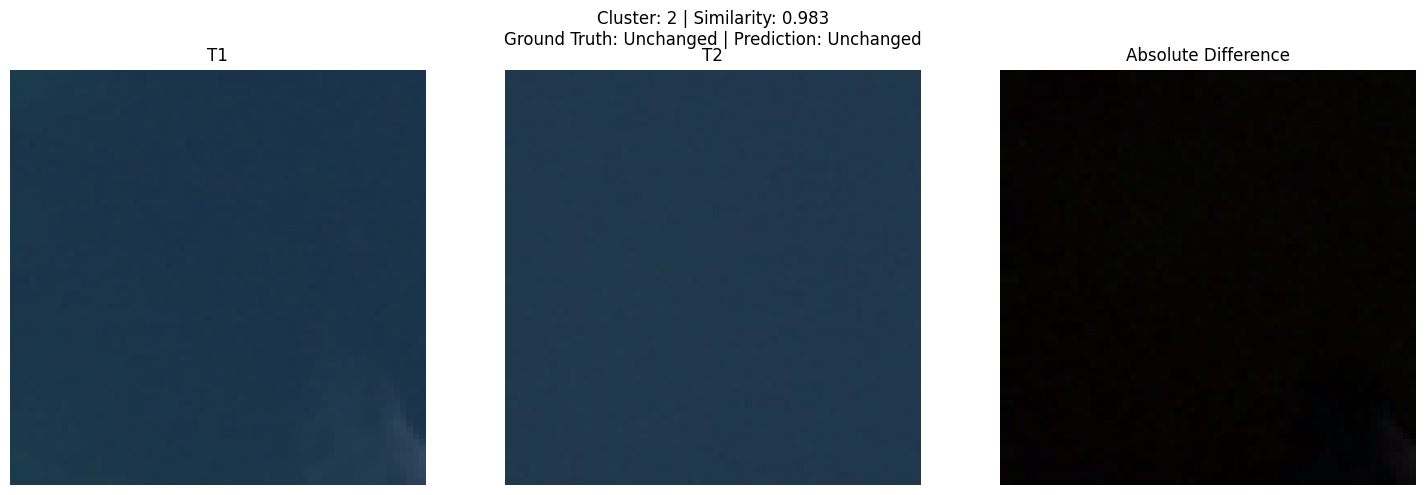

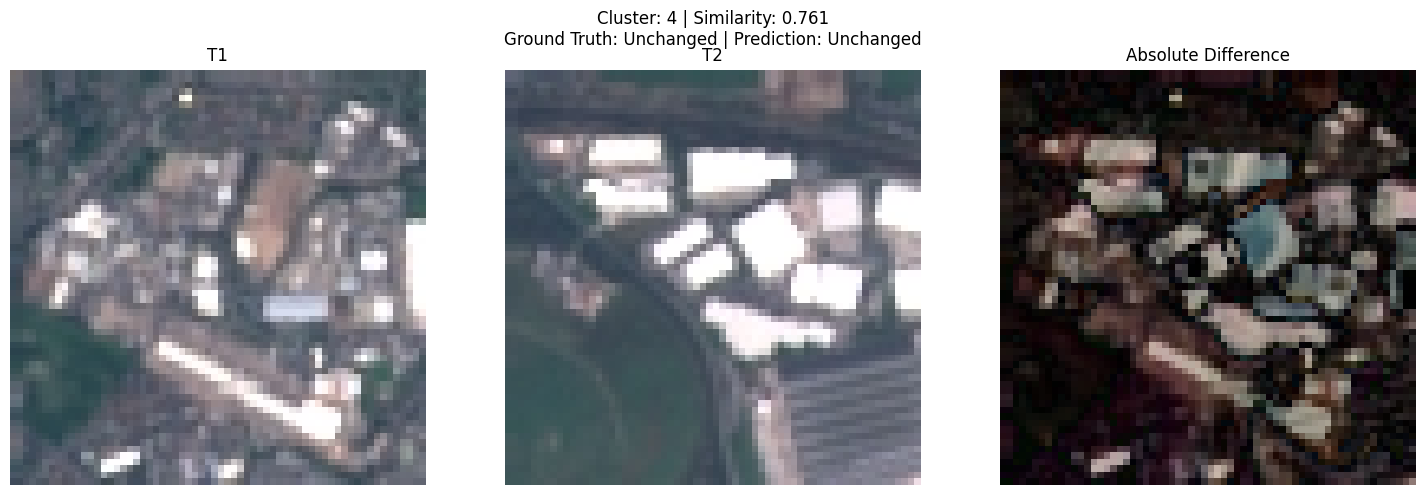

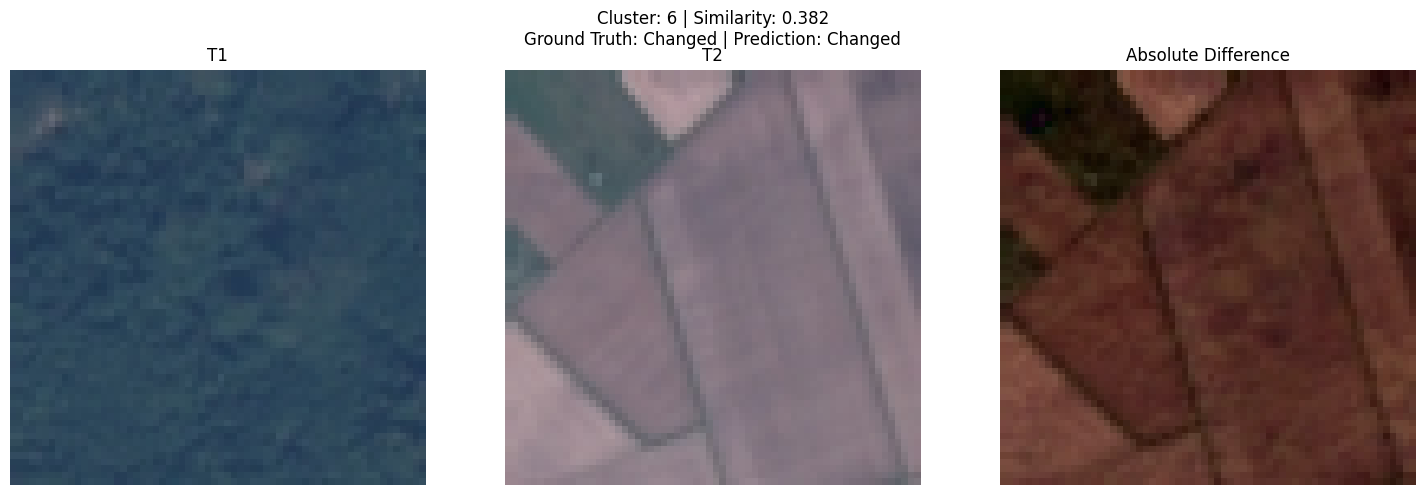

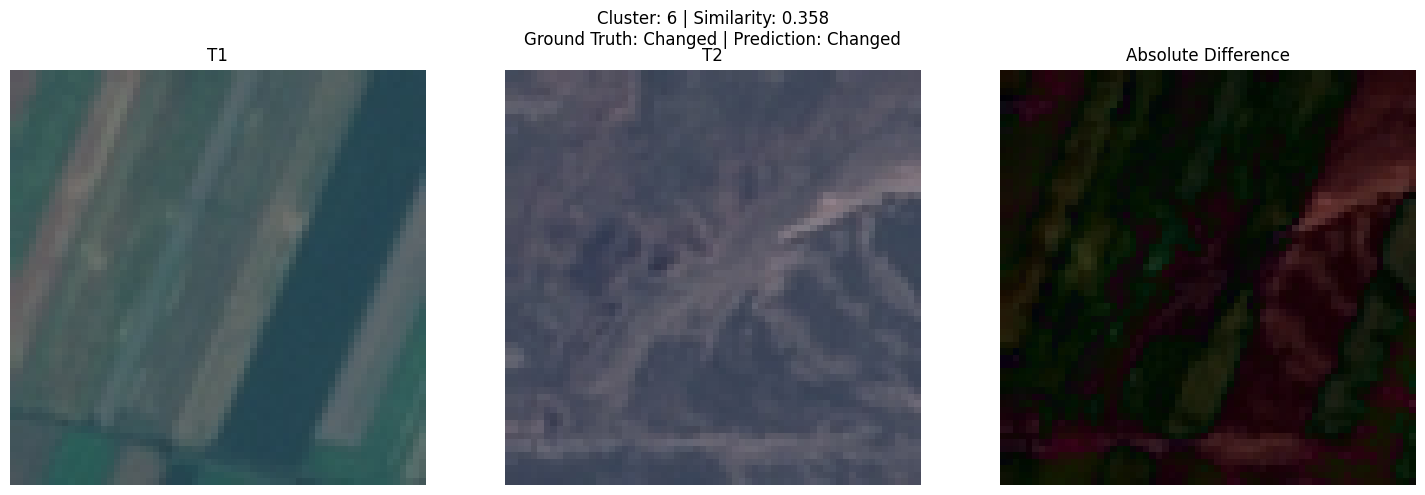

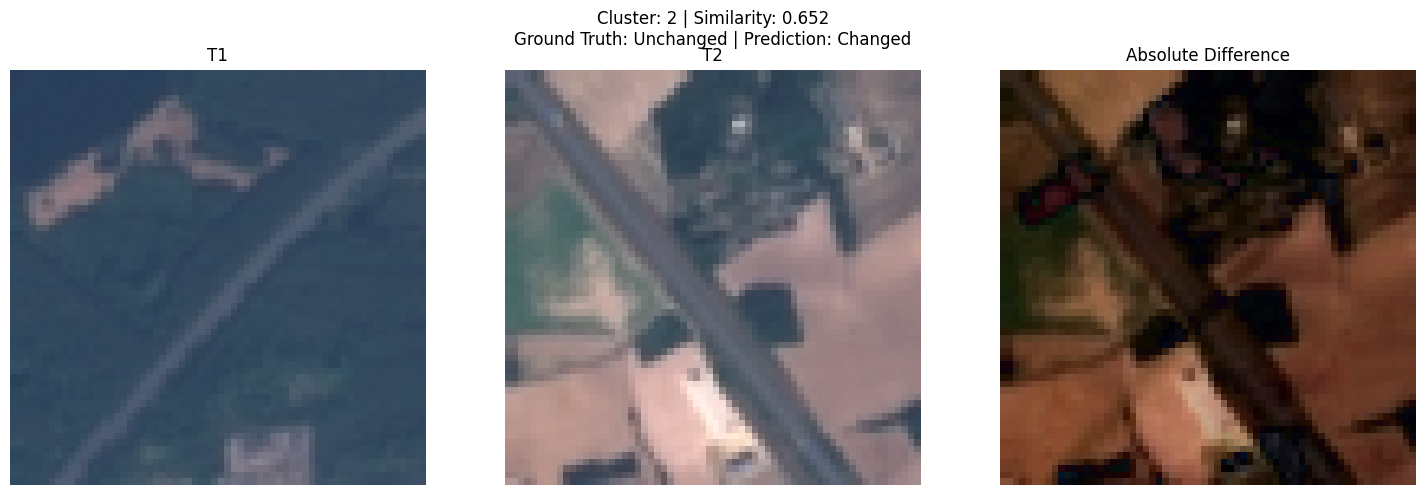

In [29]:
for idx, row in examples.iterrows():

    visualize_change_pair(
        row,
        idx + 1
    )

In [30]:
examples.to_csv(

    CHANGE_DIR /
    "selected_change_examples.csv",

    index=False

)

print("Saved selected examples.")

Saved selected examples.
